In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from urllib.parse import urlparse, parse_qs

In [2]:
import tldextract

In [3]:
train = pd.read_csv("../../train.csv")

In [4]:
train["URL"] = train["URL"].str.replace("[.]", ".", regex=False)

In [ ]:
import re
from urllib.parse import urlparse, parse_qs
import tldextract
import zlib
from collections import Counter
import math
import ipaddress

# def is_ip_address(url):
#     if not url or not isinstance(url, str):
#         return False
#     try:
#         parsed = urlparse(url if '//' in url else 'http://' + url)
#         domain = parsed.netloc.split(':')[0]
#         if not domain:
#             return False
#         ipaddress.ip_address(domain)
#         return True
#     except ValueError:
#         return False
#     except Exception:
#         return False



def url_is_whitelisted(url):
    trusted_domains = [
    # 1. 포털 / 검색엔진
    'naver.com', 'daum.net', 'google.com', 'bing.com', 'yahoo.com',

    # 2. 소셜 미디어 / 커뮤니케이션
    'facebook.com', 'instagram.com', 'twitter.com', 'x.com', 'linkedin.com',
    'whatsapp.com', 'kakao.com', 'kakaocorp.com',

    # 3. 동영상 / 스트리밍
    'youtube.com', 'netflix.com', 'twitch.tv', 'tving.com', 'watcha.com',

    # 4. 쇼핑 / 이커머스
    'amazon.com', 'gmarket.co.kr', '11st.co.kr', 'coupang.com', 'ssg.com', 'wemakeprice.com',

    # 5. 금융 / 결제
    'paypal.com', 'kbfg.com', 'shinhan.com', 'hanafn.com', 'wooribank.com', 
    'kakaobank.com', 'toss.im',

    # 6. 공공기관 / 교육
    'gov.kr', 'moe.go.kr', 'epeople.go.kr', 'pusan.ac.kr', 'ac.kr', 

    # 7. IT / 기술
    'apple.com', 'microsoft.com', 'adobe.com', 'github.com', 'stackoverflow.com'
]
    
    try:
        domain = urlparse(url if '//' in url else '//' + url).netloc.lower()
        for trusted in trusted_domains:
            if domain.endswith(trusted):
                return True
        return False
    except:
        return False



def check_similar_brand(url):
    # 자주 사용되는 브랜드/도메인 목록
    common_brands = {
        'google', 'facebook', 'amazon', 'microsoft', 'apple', 
        'netflix', 'paypal', 'twitter', 'instagram', 'linkedin',
        'youtube', 'yahoo', 'gmail', 'whatsapp', 'tiktok',
        'geocities', 'angelfire', 'newadvent', 'wikipedia',
    }
    
    # 2. 유사 브랜드 확인
    try:
        # URL 파싱
        parsed = urlparse(url if '//' in url else '//' + url)
        domain = parsed.netloc.lower() if parsed.netloc else url.lower()
        
        for brand in common_brands:
            if brand not in domain:
                similar = False
                # 비슷한 철자 패턴 확인
                patterns = [
                    brand.replace('o', '0'),
                    brand.replace('i', '1'),
                    brand.replace('l', '1'),
                    brand.replace('e', '3'),
                    brand.replace('a', '4'),
                    brand.replace('s', '5'),
                    brand + '-',
                    brand + '_',
                    brand[:-1],  # 마지막 문자 제거
                    ''.join(c + c for c in brand),  # 문자 중복
                ]
                
                for pattern in patterns:
                    if pattern in domain:
                        similar = True
                        break
                
                if similar:
                    return True  # 유사 브랜드가 발견되면 True 반환
        
    except Exception as e:
        return False  # 예외 발생 시 False 반환
    
    return False  # 유사 브랜드가 없으면 False 반환



# url 압축 비율 계산 함수
def compression_ratio(url: str) -> float:
    if not url:
        return 0.0
    original_length = len(url.encode('utf-8'))
    compressed_data = zlib.compress(url.encode('utf-8'))
    compressed_length = len(compressed_data)
    return compressed_length / original_length


def extract_features(url):
    parsed_url = urlparse(url)
    suspicious_keywords = [
        'login', 'verify', 'account', 'update', 'secure', 'banking', 
        'paypal', 'confirm', 'signin', 'auth', 'redirect', 'free', 
        'bonus', 'admin', 'support', 'server', 'password', 'click', 
        'urgent', 'immediate', 'alert', 'security', 'prompt'
    ]
    
    additional_keywords = [
        'verify', 'wallet', 'cryptocurrency', 'bitcoin', 'ethereum',
        'validation', 'authenticate', 'reset', 'recover', 'access',
        'limited', 'offer', 'prize', 'win', 'winner', 'payment',
        'bank', 'credit', 'debit', 'card', 'expire', 'suspension',
        'unusual', 'activity', 'verify', 'document', 'invoice'
    ]
    
    all_keywords = list(set(suspicious_keywords + additional_keywords))

    contains_keyword = 0
    keyword_count = 0
    for keyword in all_keywords:
        if re.search(r'\b' + keyword + r'\b', url, re.IGNORECASE):
            contains_keyword = 1
            keyword_count += 1
    
    url_length = len(url)
    extracted = tldextract.extract(url)
    tld = extracted.suffix
    domain = extracted.domain
    subdomain = extracted.subdomain

    tld_length = len(tld) if tld else 0
    common_tlds = ['com', 'org', 'net', 'edu', 'gov', 'mil', 'io', 'co', 'info', 'biz']
    is_common_tld = 1 if tld in common_tlds else 0
    country_tlds = ['us', 'uk', 'ca', 'au', 'de', 'fr', 'jp', 'cn', 'ru', 'br', 'in', 'it', 'es']
    is_country_tld = 1 if tld in country_tlds else 0
    suspicious_tlds = ['xyz', 'top', 'club', 'online', 'site', 'icu', 'vip', 'work', 'rest', 'fit']
    is_suspicious_tld = 1 if tld in suspicious_tlds else 0
    url_shorteners = ['bit.ly', 'tinyurl.com', 'goo.gl', 't.co', 'ow.ly', 'is.gd', 'buff.ly', 'adf.ly', 'tiny.cc']
    full_domain = f"{domain}.{tld}" if tld else domain
    is_shortened = 1 if full_domain in url_shorteners else 0


    domain_length = len(domain) if domain else 0
    has_subdomain = 1 if subdomain else 0
    subdomain_length = len(subdomain) if subdomain else 0
    subdomain_count = len(subdomain.split('.')) if subdomain else 0 

    path = parsed_url.path
    path_length = len(path)
    path_depth = path.count('/') if path else 0

    query = parsed_url.query
    has_query = 1 if query else 0
    query_length = len(query) if query else 0
    query_params = parse_qs(query)
    query_param_count = len(query_params) if query_params else 0

    has_fragment = 1 if parsed_url.fragment else 0
    fragment_length = len(parsed_url.fragment) if parsed_url.fragment else 0
    
    # Character type ratios
    letter_count = sum(c.isalpha() for c in url)
    digit_count = sum(c.isdigit() for c in url)
    special_char_count = len(re.findall(r'[^a-zA-Z0-9]', url))
    
    letter_ratio = letter_count / url_length if url_length > 0 else 0
    digit_ratio = digit_count / url_length if url_length > 0 else 0
    special_char_ratio = special_char_count / url_length if url_length > 0 else 0
    
    # Character distribution and entropy
    if url:
        char_counts = Counter(url)
        total_chars = len(url)
        char_frequencies = {char: count/total_chars for char, count in char_counts.items()}
        entropy = -sum(freq * math.log2(freq) for freq in char_frequencies.values())
    else:
        entropy = 0





    if url_length <= 13:
        url_length_cat = 0  
    elif url_length <= 18:
        url_length_cat = 1 
    elif url_length <= 25:
        url_length_cat = 2 
    else:
        url_length_cat = 3
        
    if url_is_whitelisted(url):
        return {
            # 화이트리스트 URL이면 특징값들을 "정상적"으로 처리되도록 설정
            "url_length_cat": 1,
            "num_dots": 1,
            "num_digits": 0,
            "num_special_chars": 1,
            "url_keyword": 0,
            "num_underbar": 0,
            "extract_consecutive_numbers": 0,
            "number": 0,
            "upper": 0,

            "is_common_tld": 1,
            "is_country_tld": 0,
            "is_suspicious_tld": 0,

            "domain_length": 5,
            "has_subdomain": 0,
            "subdomain_length": 0,
            "subdomain_count": 0,

            "path_depth": 0,
            "has_query": 0,
            "query_length": 0,
            "query_param_count": 0,
            "url_shorteners": 0,

            "compression_ratio": 1.0,
            "check_similar_brand": 0,
            "entropy": 3.0,
            "digit_ratio": 0.0,
            "special_char_ratio": 0.1
        }
    

    return {
        
        # "url_length": url_length,
        "url_length_cat": url_length_cat,
        "num_dots": url.count("."),
        "num_digits": sum(c.isdigit() for c in url),
        "num_special_chars": len(re.findall(r"[^a-zA-Z0-9]", url)),
        "url_keyword": contains_keyword,
        # "url_keyword_count": keyword_count,
        "num_underbar": url.count("_"),
        "extract_consecutive_numbers": int(bool(re.findall(r'(\d)\1+', url))),
        "number": int(bool(len(re.findall(r'(\d)(?!\1)(\d)(?!\2)(\d)', url)))),
        "upper": int(any(c.isupper() for c in url)),

        "is_common_tld": is_common_tld,
        "is_country_tld": is_country_tld,
        "is_suspicious_tld": is_suspicious_tld,

        "domain_length": domain_length,
        "has_subdomain": has_subdomain,
        "subdomain_length": subdomain_length,
        "subdomain_count": subdomain_count,

        # "path_length": path_length,
        "path_depth": path_depth,
        "has_query": has_query,
        "query_length": query_length,
        "query_param_count": query_param_count,
        # "has_fragment": has_fragment,
        # "fragment_length": fragment_length,
        "url_shorteners": is_shortened,

        # 새로 추가된 특성
        "compression_ratio": compression_ratio(url),
        "check_similar_brand" : check_similar_brand(url),
 
        # Advanced text analysis
        "entropy": entropy,
        #"letter_ratio": letter_ratio,
        "digit_ratio": digit_ratio,
        "special_char_ratio": special_char_ratio,
        
        # "is_ip_address" : is_ip_address(url)
        
    }


In [6]:
def process_chunks(train, chunk_size, extract_features):
    """
    train: DataFrame, 원본 데이터프레임
    chunk_size: int, 한 번에 처리할 URL의 개수
    extract_features: 함수, 각 URL에 대해 특징을 추출하는 함수
    
    return: 처리된 DataFrame
    """
    # 청크로 나누기
    chunks = [train["URL"][i:i + chunk_size] for i in range(0, len(train), chunk_size)]
    
    # 각 청크에 대해 apply 및 json_normalize 처리 후 결과를 저장
    chunk_results = []
    for chunk in chunks:
        # 각 청크에 대해 extract_features 함수를 적용
        chunk_features = chunk.apply(extract_features)
      
        # json_normalize 적용
        chunk_results.append(pd.json_normalize(chunk_features))
    
    # 처리된 청크 결과를 합침
    return pd.concat(chunk_results, ignore_index=True)


In [7]:
train_features_df = process_chunks(train, chunk_size=100000, extract_features=extract_features)

In [8]:
train_features_df

,url_length_cat,num_dots,num_digits,num_special_chars,url_keyword,num_underbar,extract_consecutive_numbers,number,upper,is_common_tld,...,has_query,query_length,query_param_count,url_shorteners,compression_ratio,check_similar_brand,entropy,digit_ratio,special_char_ratio,is_ip_address
0,1,3,0,3,0,0,0,0,0,0,...,0,0,0,0,1.444444,False,3.308271,0.000000,0.166667,False
1,2,3,0,3,0,0,0,0,0,0,...,0,0,0,0,1.421053,False,3.471354,0.000000,0.157895,False
2,2,2,0,2,0,0,0,0,0,0,...,0,0,0,0,1.380952,False,3.272804,0.000000,0.095238,False
3,2,3,0,3,0,0,0,0,0,0,...,0,0,0,0,1.363636,False,3.533771,0.000000,0.136364,False
4,3,2,2,5,1,0,0,0,1,0,...,0,0,0,0,1.242424,False,3.772450,0.060606,0.151515,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995051,0,2,0,2,0,0,0,0,0,0,...,0,0,0,0,1.800000,False,2.921928,0.000000,0.200000,False
6995052,2,2,0,2,0,0,0,0,0,1,...,0,0,0,0,1.400000,False,3.684184,0.000000,0.100000,False
6995053,3,2,5,4,0,0,1,0,0,1,...,0,0,0,0,1.100000,False,4.130881,0.100000,0.080000,False
6995054,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.571429,False,3.324863,0.000000,0.071429,False


In [9]:
train_features_df[train_features_df['is_ip_address'].isna()]

,url_length_cat,num_dots,num_digits,num_special_chars,url_keyword,num_underbar,extract_consecutive_numbers,number,upper,is_common_tld,...,has_query,query_length,query_param_count,url_shorteners,compression_ratio,check_similar_brand,entropy,digit_ratio,special_char_ratio,is_ip_address
3132,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
4387,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
4427,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
4558,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
4886,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6994712,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
6994876,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
6994893,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN
6994899,1,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1.0,0,3.0,0.0,0.1,NaN


In [10]:
print(train.loc[3132])
print(train.loc[4387])

ID       TRAIN_0003132
URL        c.ksc.ac.kr
label                1
Name: 3132, dtype: object
ID                                           TRAIN_0004387
URL      apachepowersports-tx.com/din/iswxsas7e18yqerjh...
label                                                    1
Name: 4387, dtype: object


In [11]:
url = "c.ksc.ac.kr"
parsed = urlparse(url if '//' in url else 'http://' + url)
domain = parsed.netloc.split(':')[0]
print(domain)
is_ip_address(url)

c.ksc.ac.kr


False

In [12]:
processed_train = pd.concat([train, train_features_df], axis=1)

In [13]:
processed_train.describe()

,label,url_length_cat,num_dots,num_digits,num_special_chars,url_keyword,num_underbar,extract_consecutive_numbers,number,upper,...,subdomain_count,path_depth,has_query,query_length,query_param_count,url_shorteners,compression_ratio,entropy,digit_ratio,special_char_ratio
count,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,...,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06,6.995056e+06
mean,2.237147e-01,1.443553e+00,1.546945e+00,1.634359e+00,2.663572e+00,3.707890e-02,4.500550e-02,5.646374e-02,8.128041e-02,3.577641e-02,...,2.660177e-01,6.056849e-01,2.722137e-02,1.915589e+00,4.228915e-02,1.842158e-03,1.455253e+00,3.536043e+00,2.904243e-02,1.102289e-01
std,4.167331e-01,1.116120e+00,1.010079e+00,9.827940e+00,7.161846e+00,1.889552e-01,6.023703e-01,2.308151e-01,2.732653e-01,1.857322e-01,...,6.272396e-01,1.600321e+00,1.627279e-01,1.970207e+01,3.520885e-01,4.288082e-02,2.485654e-01,4.789894e-01,8.255957e-02,4.633803e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.018182e-02,-0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.307692e+00,3.238901e+00,0.000000e+00,7.142857e-02
50%,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.444444e+00,3.506891e+00,0.000000e+00,1.034483e-01
75%,0.000000e+00,2.000000e+00,2.000000e+00,0.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.615385e+00,3.796218e+00,0.000000e+00,1.428571e-01
max,1.000000e+00,3.000000e+00,1.710000e+02,2.011000e+03,8.198000e+03,1.000000e+00,1.360000e+02,1.000000e+00,1.000000e+00,1.000000e+00,...,3.800000e+01,1.360000e+02,1.000000e+00,8.367000e+03,1.310000e+02,1.000000e+00,5.000000e+00,6.570554e+00,9.545455e-01,1.000000e+00


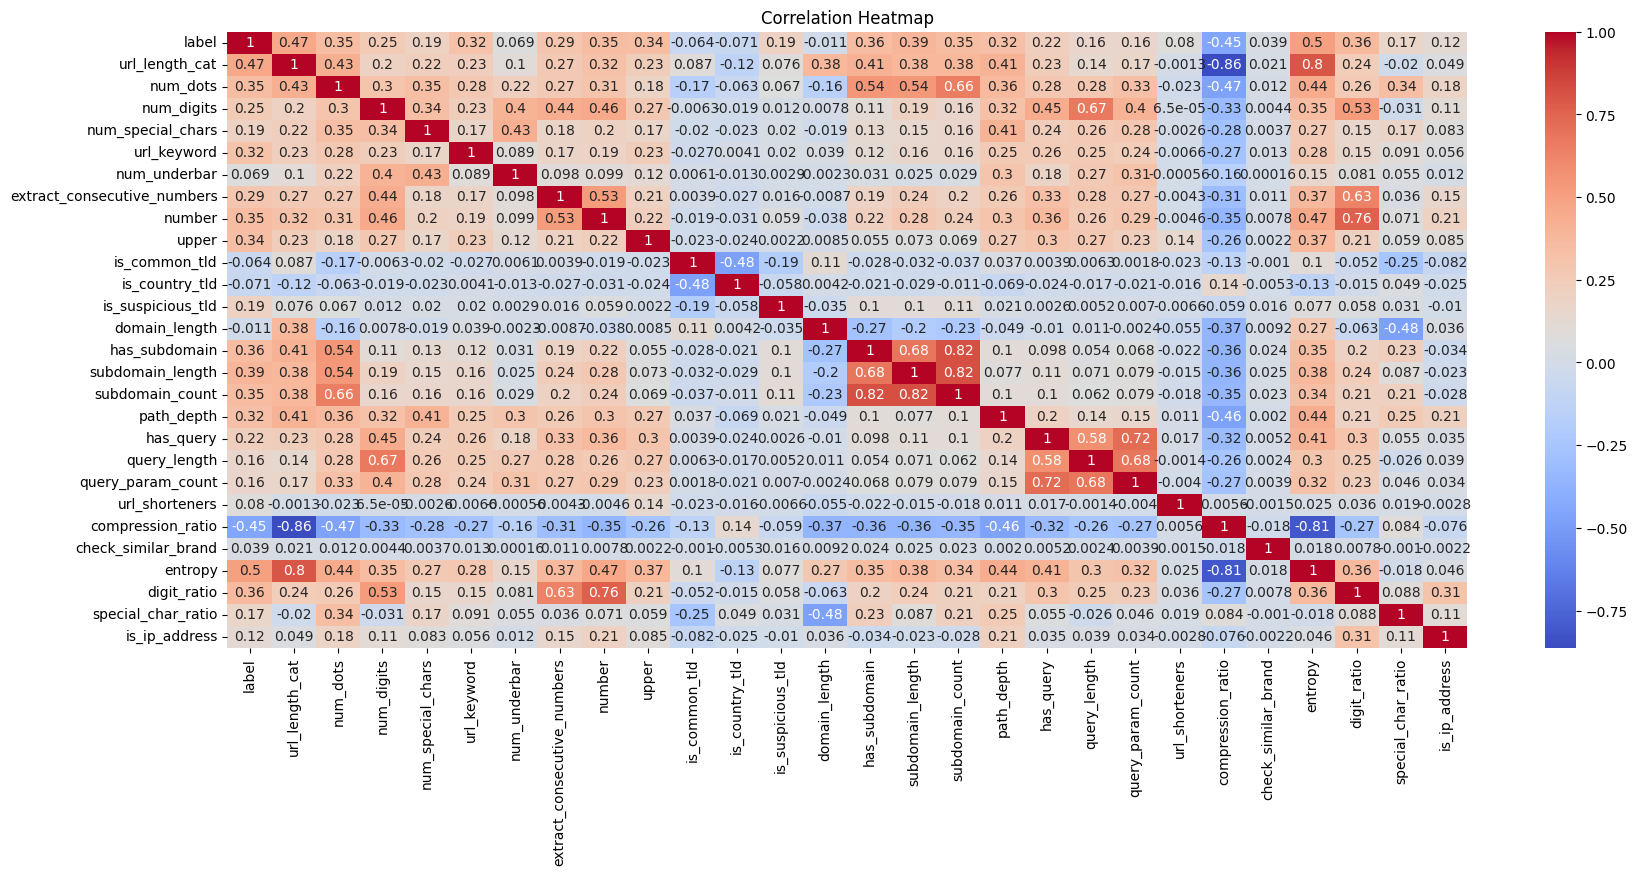

In [14]:
corr = processed_train.drop(["ID","URL"], axis=1)

import seaborn as sns

plt.figure(figsize=(20, 8))
sns.heatmap(corr.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [15]:
X = processed_train.drop(["ID", "URL","label"], axis=1)
X = X.astype(np.float32)


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm  # statsmodels를 임포트

# 상수항 추가
X_with_const = add_constant(X)

# VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i+1) for i in range(len(X.columns))]

print(vif_data)

MissingDataError: exog contains inf or nans

In [ ]:
X = processed_train.drop(["ID","URL", "label"], axis=1)
y = processed_train["label"]

In [ ]:
from sklearn.model_selection import train_test_split

# 1차 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)


In [ ]:
# from imblearn.pipeline import Pipeline
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.over_sampling import SMOTE

# # 언더샘플링 - 다수 클래스(정상) 60%로 줄임
# under = RandomUnderSampler(sampling_strategy=0.6, random_state=42)

# # 2단계: 오버샘플링 - 소수 클래스(악성)를 다수 클래스 수에 맞게 증강
# over = SMOTE(sampling_strategy='auto', random_state=42)

# # 파이프라인 구성
# hybrid_sampler = Pipeline(steps=[
#     ('undersample', under),
#     ('oversample', over)
# ])

# # 샘플링 적용
# X_train, y_train = hybrid_sampler.fit_resample(X_train, y_train)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pickle
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


with open('scaler.pkl','wb') as f:
    pickle.dump(scaler, f)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

def build_model(input_dim, learning_rate=0.001):
    """
    딥러닝 모델 생성 및 컴파일

    Parameters:
        input_dim (int): 입력 특성 수 (X.shape[1])
        learning_rate (float): 옵티마이저 학습률

    Returns:
        tf.keras.Model: 컴파일된 Keras Sequential 모델
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ], name="Model")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [ ]:
model = build_model(input_dim=X_train_scaled.shape[1])
model.summary()

In [ ]:
history = model.fit(X_train_scaled, y_train,
                    epochs=20, batch_size=128,
                    validation_split=0.2)


In [ ]:
# 모델 평가 (검증 데이터 기준)
loss, accuracy = model.evaluate(X_test_scaled, y_test)

# 결과 출력
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

In [ ]:
y_test_pred = model.predict(X_test_scaled)  # 테스트 데이터에 대해 예측
y_test_pred = (y_test_pred > 0.3549).astype(int)  # 이진 분류이므로 0.5를 기준으로 0과 1로 변환


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 혼동행렬 계산
cm = confusion_matrix(y_test, y_test_pred)

# 시각화 (heatmap)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Malicious"], yticklabels=["Normal", "Malicious"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, average_precision_score, f1_score, accuracy_score, roc_auc_score

# 테스트 데이터에 대한 예측 확률 (양성 클래스)
y_test_pred_prob = model.predict(X_test_scaled)

# 여러 임계값에서 F1 Score 계산
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_pred_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)  # 0으로 나누는 오류 방지

# F1 Score가 최대가 되는 임계값 선택
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"최적의 임계값: {best_threshold:.4f}")

# f1을 활용한 임계값을 기준으로 클래스 예측
y_test_pred_class = (y_test_pred_prob >= best_threshold).astype(int)

# Recall 계산
recall = recall_score(y_test, y_test_pred_class)
print(f"Test Recall: {recall:.4f}")

# Precision 계산
precision = precision_score(y_test, y_test_pred_class)
print(f"Test Precision: {precision:.4f}")

# AUC-PR 점수 계산
aucpr_score = average_precision_score(y_test, y_test_pred_prob)
print(f"AUC-PR: {aucpr_score:.4f}")

# F1 Score 계산
print(f"F1 Score  : {f1_score(y_test, y_test_pred_class):.4f}")

# Accuracy 점수 계산
accuracy = accuracy_score(y_test, y_test_pred_class)
print(f"Accuracy: {accuracy:.4f}")

# ROC-AUC 점수 계산
roc_auc = roc_auc_score(y_test, y_test_pred_prob)
print(f"ROC-AUC: {roc_auc:.4f}")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# threshold 간단히 100개로 나눔
thresholds = np.linspace(0, 1, 100)

f1_scores = []
accuracies = []

for t in thresholds:
    y_pred_class = (y_test_pred_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_class))
    accuracies.append(accuracy_score(y_test, y_pred_class))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(thresholds, f1_scores, label='F1 Score', color='blue')
plt.plot(thresholds, accuracies, label='Accuracy', color='green')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.2f}')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('F1 Score & Accuracy vs Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# DataFrame 컬럼명 지정 (중요!)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 샘플 추출
X_sample = X_test_scaled_df.sample(n=1000, random_state=42)

# SHAP 값 계산
explainer = shap.Explainer(model, X_sample)
shap_values = explainer(X_sample)

# 평균 절대 SHAP 값 계산
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# DataFrame으로 정리 (feature name + 중요도)
shap_df = pd.DataFrame({
    'feature': X_sample.columns,
    'importance': mean_abs_shap
})

# 중요도 기준 정렬
shap_df = shap_df.sort_values(by='importance', ascending=False)

# 상위 N개 선택
top_n = 30
shap_df_top = shap_df.head(top_n)

# Bar plot 그리기
plt.figure(figsize=(10, 8))
bars = plt.barh(shap_df_top['feature'][::-1], shap_df_top['importance'][::-1], color='skyblue')

# 수치(label) 추가
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.4f}', va='center')

plt.xlabel('Mean |SHAP value|')
plt.title('Top SHAP Feature Importances')
plt.tight_layout()
plt.show()


In [ ]:
# import tensorflow as tf
# from sklearn.metrics import roc_auc_score

# # 중요도 기준으로 특성 제거
# # numpy 배열을 DataFrame으로 변환 (컬럼명 유지)
# X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
# X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# # 중요도 낮은 특성 제거
# threshold = 0.0001
# low_importance_features = shap_df[shap_df['importance'] < threshold]['feature'].tolist()

# print(f"제거할 특성 수: {len(low_importance_features)}")
# print(f"제거 된 특성 : {low_importance_features}")

# # 제거한 특성 반영
# X_train_reduced = X_train_scaled_df.drop(columns=low_importance_features)
# X_test_reduced = X_test_scaled_df.drop(columns=low_importance_features)

# # numpy로 변환
# X_train_np = X_train_reduced.to_numpy()
# X_test_np = X_test_reduced.to_numpy()


# model = build_model(input_dim=X_train_np.shape[1])

# history = model.fit(X_train_np, y_train,
#                     epochs=30, batch_size=256,
#                     validation_split=0.2)




In [ ]:
# # 예측 및 평가
# y_pred_reduced = model.predict(X_test_np).ravel()
# roc_reduced = roc_auc_score(y_test, y_pred_reduced)

# print(f"SHAP 기반 특성 제거 후 ROC AUC: {roc_reduced:.4f}")

In [ ]:
# model.save("White_list_model.keras")

In [ ]:
# from tensorflow.keras.models import load_model

# model = load_model('White_list_model.keras')

In [ ]:
# url = "https://www.11st.co.kr/?gad_source=1&gclid=CjwKCAjwn6LABhBSEiwAsNJrjqtgvZC-SH5p6dnrQwDUjxMsWp96y_Jouf39QXALiirxR5KErWDNzhoCHZgQAvD_BwE&gbraid=0AAAAADQ_R8LZJlCP90c4HNMof-oD17G2u&utm_term=11+%B9%F8%B0%A1&utm_campaign=%B1%B8%B1%DBPC_11%B9%F8%B0%A1&utm_source=%B1%B8%B1%DB_PC_S&utm_medium=%B0%CB%BB%F6"

# features = extract_features(url)

# input_df = pd.DataFrame([features])

# scaler = MinMaxScaler()
# scaler.fit(input_df)

# scaled_input = scaler.transform(input_df)

In [ ]:
# prediction = model.predict(scaled_input)

# # 예측값 출력 (확률 값)
# predicted_prob = prediction[0][0]

# # 임계값 기준으로 라벨 결정
# predicted_label = int(predicted_prob > 0.4174)

# # 결과 출력
# print(f"예측 확률: {predicted_prob:.4f}")
# print(f"예측 결과: {'악성' if predicted_label else '정상'}")
